In [1]:
import os
import sys

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt
import gc

lib_decompre = "/var/home/dotamthuc/Works/Compress3DGS/Differentiable3DPC-Decompression-and-Rendering/"
sys.path.insert(0, lib_decompre)

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene
import decompress_render


lib_svraster = "/var/home/dotamthuc/Works/Compress3DGS/Baselines/svraster"
sys.path.insert(0, lib_svraster)
from src.sparse_voxel_model import SparseVoxelModel

np.set_printoptions(precision=3, suppress=True)

torch.cuda.set_per_process_memory_fraction(0.9, 0)

# 00 - Script

In [2]:
def load_geometry_from_sparse_voxels_model(sourse_path, load_attribute_field=True):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=3,
        ss=1.5,
        white_background=False,
        black_background=False,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    #morton_code
    geometry_info["morton_code_tensor"] = voxel_model_frame.octpath.clone().detach()

    #vox_roots
    vox_roots = (voxel_model_frame.vox_center - 0.5 * voxel_model_frame.vox_size)
    geometry_info["vox_roots_tensor"] = vox_roots.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()

    # Geometry conners
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame._geo_grid_pts.clone().detach()

    # Colors
    if load_attribute_field:
        # SH0 = 0.28209479177387814
        # static_color  = (voxel_model_frame._sh0 * SH0 + 0.5).clone().detach()
        # static_color[static_color<0.0] = 0.0
        # geometry_info["vox_params_color_tensor"] = static_color
        geometry_info["vox_params_color_tensor"] = torch.concat([
            voxel_model_frame.sh0[:, None, :], voxel_model_frame.shs[:, :, :]
        ], dim=1)


    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


def resize_rendering(render, size, mode='bilinear', align_corners=False):
    return torch.nn.functional.interpolate(
        render[None], size=size, mode=mode, align_corners=align_corners, antialias=True)[0]


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1,
        load_attribute_field=True
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path, load_attribute_field)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        if load_attribute_field:
            self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]
        else:
            self.voxel_attribute_field = torch.full(
                [self.num_voxels, 3], 0.0, 
                dtype=torch.float32
            )
    
    def apply_phi(self, view_info):
        ss = 1.5
        w_src, h_src = view_info.render_width, view_info.render_height
        w, h = round(w_src * ss), round(h_src * ss)
        w_ss, h_ss = w / w_src, h / h_src

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=w,#view_info.render_width, 
            image_height=h,#view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx * w_ss,
            cy=view_info.cy * h_ss,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, out_depth, out_T, max_w = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )
        out_color = out_color + out_T * out_color.mean((1,2), keepdim=True)
        # print(f"color.shape={out_color.shape}")
        out_color = resize_rendering(out_color, size=(h_src, w_src))

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image
    
    
    def apply_phi_with_F(self, voxel_attribute, view_info):

        ss = 1.5
        w_src, h_src = view_info.render_width, view_info.render_height
        w, h = round(w_src * ss), round(h_src * ss)
        w_ss, h_ss = w / w_src, h / h_src

        # if voxel_attribute.shape != (self.num_voxels, 3):
        #     raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=w,#view_info.render_width, 
            image_height=h,#view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx * w_ss,
            cy=view_info.cy * h_ss,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, out_depth, out_T, max_w = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute,
        )
        out_color = out_color + out_T * out_color.mean((1,2), keepdim=True)
        # print(f"color.shape={out_color.shape}")
        out_color = resize_rendering(out_color, size=(h_src, w_src))

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()


        return rendered_image


In [3]:

SH_C0 = 0.28209479177387814
SH_C1 = 0.4886025119029199
SH_C2 = [
    1.0925484305920792,
    -1.0925484305920792,
    0.31539156525252005,
    -1.0925484305920792,
    0.5462742152960396
]
SH_C3 = [
    -0.5900435899266435,
    2.890611442640554,
    -0.4570457994644658,
    0.3731763325901154,
    -0.4570457994644658,
    1.445305721320277,
    -0.5900435899266435
]
def computeColorFromSH(
        input_dir, coefs_mask,
    ):

    dir_norm = np.sqrt(np.sum((input_dir**2)))
    # print(f"dir={dir} dir_norm={dir_norm}")
    input_dir = input_dir / dir_norm
    # print(f"Dir={input_dir}")

    # // The implementation is loosely based on code for
    # // "Differentiable Point-Based Radiance Fields for
    # // Efficient View Synthesis" by Zhang et al. (2022)
    sh = coefs_mask[1:, :]
    sh0 = coefs_mask[0, :]

    # DEG 0
    result = SH_C0 * sh0

    #DEG 1
    x,y,z = input_dir[0], input_dir[1], input_dir[2]
    result = result - SH_C1 * y * sh[0] + SH_C1 * z * sh[1] - SH_C1 * x * sh[2]

    #DEG 2
    xx = x * x
    yy = y * y
    zz = z * z
    xy = x * y
    yz = y * z
    xz = x * z
    result = result + \
        SH_C2[0] * xy * sh[3] + \
        SH_C2[1] * yz * sh[4] + \
        SH_C2[2] * (2.0 * zz - xx - yy) * sh[5] + \
        SH_C2[3] * xz * sh[6] + \
        SH_C2[4] * (xx - yy) * sh[7]
    
    # DEG 3
    result = result + \
        SH_C3[0] * y * (3.0 * xx - yy) * sh[8] + \
        SH_C3[1] * xy * z * sh[9] + \
        SH_C3[2] * y * (4.0 * zz - xx - yy) * sh[10] + \
        SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) * sh[11] + \
        SH_C3[4] * x * (4.0 * zz - xx - yy) * sh[12] + \
        SH_C3[5] * z * (xx - yy) * sh[13] + \
        SH_C3[6] * x * (xx - 3.0 * yy) * sh[14] 

    result = result
    # result[result<=0] = 0.0
    return result


# 01 - Load data

In [4]:
scene_sourse = "/var/home/dotamthuc/Works/Compress3DGS/Data/mip-nerf-360/{}/".format("bicycle")
scene_dataset = Scene(
    scene_sourse, image_dir_name="images",
    res_downscale=0.0, res_width=1600,
    test_view_every=8,
    load_test_only=True
)
test_views = scene_dataset.get_test_views()
test_one_view = scene_dataset.get_test_views()[0]

Read dataset in COLMAP format.
Done reading and creating views: 0 train views and 25 encoding views


In [5]:

checkpoint = "/var/home/dotamthuc/Works/Compress3DGS/Results/SVRaster-small/mip-nerf-360/bicycle/rate00/checkpoints/iter030000_model.pt"
ref_denfield= DensityField(checkpoint)

####
voxel_morton_code = ref_denfield.voxel_morton_code.detach().cpu().numpy()
voxel_position = ref_denfield.voxel_position.detach().cpu().numpy()
voxel_size = ref_denfield.voxel_size.detach().cpu().numpy()
voxel2corner = ref_denfield.voxel2corner.detach().cpu().numpy()
corner_geo_params = ref_denfield.corner_geo_params.detach().cpu().numpy()
num_voxels = ref_denfield.num_voxels
voxel_attribute_field = ref_denfield.voxel_attribute_field.detach().cpu().numpy()



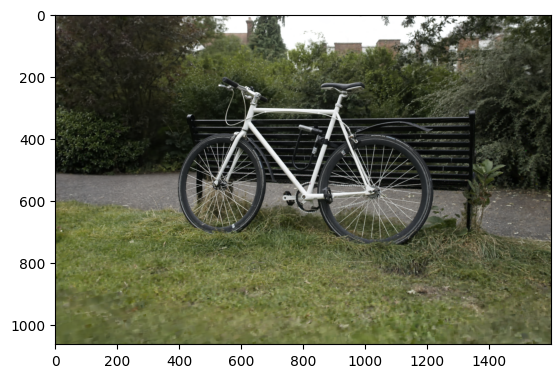

In [6]:
tensor_img_target = ref_denfield.apply_phi(test_views[0]).detach()
img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
plt.imshow(img_target)
plt.show()

# 01 - No transform

In [ ]:
U = np.eye(48)
X_transformed = (voxel_attribute_field.reshape(-1, 48) @ U)

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 48):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs] = X_transformed[:, :ncoefs]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate([test_one_view]):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=25.26497661368255
ncoefs=2, psnr=25.367631757270175
ncoefs=3, psnr=25.804179162903672
ncoefs=4, psnr=26.994924532077874
ncoefs=5, psnr=27.38765063716712
ncoefs=6, psnr=27.516087865759808
ncoefs=7, psnr=27.728791933035104
ncoefs=8, psnr=28.877077292152013
ncoefs=9, psnr=29.599757026456075
ncoefs=10, psnr=29.80422063212792
ncoefs=11, psnr=30.142999624185457
ncoefs=12, psnr=30.279512053307855
ncoefs=13, psnr=30.930584154323036
ncoefs=14, psnr=32.85231262768074
ncoefs=15, psnr=37.20537381752492
psnr=[25.26497661368255, 25.367631757270175, 25.804179162903672, 26.994924532077874, 27.38765063716712, 27.516087865759808, 27.728791933035104, 28.877077292152013, 29.599757026456075, 29.80422063212792, 30.142999624185457, 30.279512053307855, 30.930584154323036, 32.85231262768074, 37.20537381752492]


# 02 - KTL results

In [47]:
S

array([19210286.   ,  1384413.2  ,   188643.6  ,   143146.55 ,
         104829.15 ,    95887.12 ,    84447.414,    77127.86 ,
          69013.48 ,    63085.28 ,    58440.707,    51884.543,
          48059.68 ,    44725.434,    40191.28 ,    25704.584,
          24778.938,    13408.011,     4591.867,     3990.866,
           3512.572,     3168.862,     2932.04 ,     2765.735,
           2270.855,     2170.831,     1857.832,     1793.289,
           1746.958,     1514.665,     1034.227,      920.354,
            794.3  ,      623.604,      614.613,      512.738,
            474.59 ,      445.385,      421.555,      405.625,
            366.493,      316.791,      302.389,      268.298,
            249.163,      173.619,      143.124,       74.747],
      dtype=float32)

In [45]:
XtX = voxel_attribute_field.reshape(-1, 48).T @ voxel_attribute_field.reshape(-1, 48)
# # C = np.cov(X, rowvar=False)
# # S, U = np.linalg.eig(C)
U, S, V = np.linalg.svd(XtX)
X_transformed = (voxel_attribute_field.reshape(-1, 48) @ U)

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 16):
    truncated_coefs = np.zeros_like(X_transformed)

    truncated_coefs[:, :ncoefs*3] = X_transformed[:, :ncoefs*3]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate([test_one_view]):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=25.362115430345284
ncoefs=2, psnr=25.783150938596417
ncoefs=3, psnr=27.683004615419588
ncoefs=4, psnr=32.36940745656986
ncoefs=5, psnr=38.516247195627386
ncoefs=6, psnr=38.857246870797155
ncoefs=7, psnr=40.28183268807644
ncoefs=8, psnr=42.067181472179875
ncoefs=9, psnr=43.25667483836607
ncoefs=10, psnr=46.413204353839305
ncoefs=11, psnr=48.63292787592849
ncoefs=12, psnr=48.845950058006835
ncoefs=13, psnr=49.75211823882447
ncoefs=14, psnr=51.0638107361913
ncoefs=15, psnr=61.888529366262446
psnr=[25.362115430345284, 25.783150938596417, 27.683004615419588, 32.36940745656986, 38.516247195627386, 38.857246870797155, 40.28183268807644, 42.067181472179875, 43.25667483836607, 46.413204353839305, 48.63292787592849, 48.845950058006835, 49.75211823882447, 51.0638107361913, 61.888529366262446]


Text(0.5, 1.0, 'Bicycle Scene')

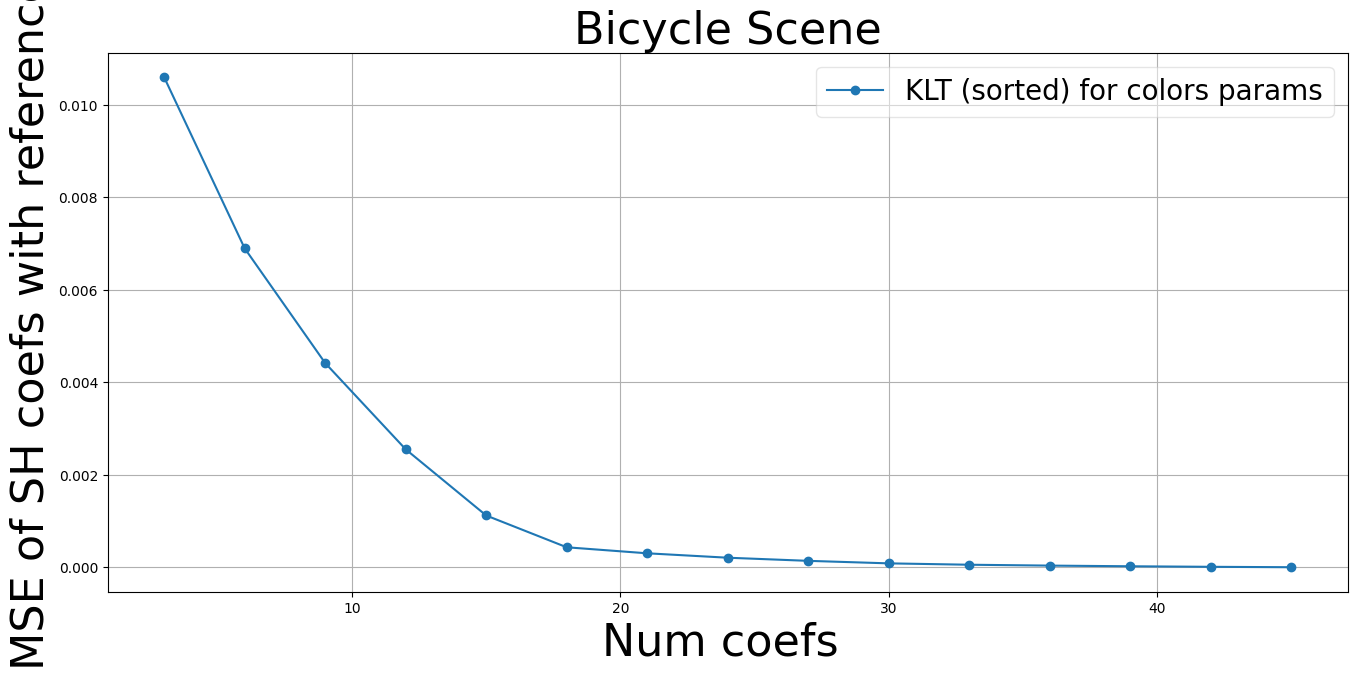

In [46]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


## BASELINE 
mse = np.array(dist_sh)
ax.plot(np.arange(1, 16)*3, mse, '-o', label="KLT (sorted) for colors params")


############ 
# plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Num coefs ', fontsize=32)
plt.ylabel('MSE of SH coefs with reference', fontsize=32)
plt.title('Bicycle Scene', fontsize=32)

In [14]:
# fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


# ## BASELINE 
# psnr_sh = -10 * np.log10(np.array(dist_sh))
# ax.plot(np.arange(1, 16)*3, dist_sh, '-o', label="KLT (sorted) for colors params")


# ############ 
# # plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# # plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
# plt.grid()
# plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
# plt.xlabel('Num coefs ', fontsize=32)
# plt.ylabel('MSE of SH coefs with reference', fontsize=22)
# plt.title('Bicycle Scene', fontsize=32)

# Fixed Universal Direction

In [45]:
list_dir = [
    (-1, -1, -1), (-1, -1, 0), (-1, -1, 1), 
    (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), 
    (-1, 1, -1), (-1, 1, 0), (-1, 1, 1),
    (0, -1, -1), (0, -1, 0), (0, -1, 1), 
    (0, 0, -1), (0, 0, 1), 
    (0, 1, -1), (0, 1, 0), (0, 1, 1), 
    (1, -1, -1), (1, -1, 0), (1, -1, 1), 
    (1, 0, -1), (1, 0, 0), (1, 0, 1), 
    (1, 1, -1), (1, 1, 0), (1, 1, 1)
]
transformM = []
for dir in list_dir:
    out_dir = []
    for c_i in range(16):
        out_c_i = []
        for k in range(3):
            coefs = np.zeros((16, 3))
            coefs[c_i, k] = 1.0
            out_c_i.append(computeColorFromSH(np.array(dir), coefs))
        out_dir.append(out_c_i)
    transformM.append(out_dir)
    
transformM = np.array(transformM)
print(f"transformM.shape={transformM.shape}")
transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(26*3, 16*3)
print(f"transformM.shape={transformM.shape}")

# transformM = []
# for dir_i in range(10):
#     out_dir = []
#     for c_i in range(16):
#         out_c_i = []
#         for k in range(3):
#             coefs = np.zeros((16, 3))
#             coefs[c_i, k] = 1.0
#             out_c_i.append(computeColorFromSH(np.random.uniform(-1, 1, size=(3)), coefs))
#         out_dir.append(out_c_i)
#     transformM.append(out_dir)
    
# transformM = np.array(transformM)
# print(f"transformM.shape={transformM.shape}")
# transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(10*3, 48)
# print(f"transformM.shape={transformM.shape}")

transformM.shape=(26, 16, 3, 3)
transformM.shape=(78, 48)


In [49]:
M = transformM[:, :]
MtM = (M.T @ M)
U, S, Vt = np.linalg.svd(MtM)
MtT_sqrt_inv = U @ np.diag(1/np.sqrt(S)) @ Vt

# U =  U[:, np.argsort(S)]
transform = MtM @ MtT_sqrt_inv
inv_transform = MtT_sqrt_inv

X_transformed = (voxel_attribute_field.reshape(-1, 48) @ transform)
variance = np.std(X_transformed, axis=0)
order = np.argsort(-variance)

transform = transform[:, order]
inv_transform = inv_transform[order, :]

X_transformed = (voxel_attribute_field.reshape(-1, 48) @ transform)
np.std(X_transformed, axis=0).reshape((16, 3))
order

array([ 2,  0,  1, 32, 35, 17, 14, 47, 30, 31, 29, 33, 34, 44, 41, 38, 45,
       15, 16, 46,  5, 27, 12, 13, 28, 42, 39, 23, 43, 36, 40,  8, 37, 20,
       26, 11,  3,  4, 21, 18, 22, 24, 25,  6, 19,  9,  7, 10])

In [50]:
transform @ inv_transform

array([[ 1.,  0., -0., ..., -0.,  0.,  0.],
       [ 0.,  1., -0., ...,  0., -0., -0.],
       [-0.,  0.,  1., ..., -0.,  0.,  0.],
       ...,
       [ 0., -0., -0., ...,  1.,  0., -0.],
       [-0.,  0., -0., ..., -0.,  1.,  0.],
       [ 0., -0., -0., ...,  0.,  0.,  1.]])

In [51]:

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 16):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs*3] = X_transformed[:, :ncoefs*3]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ inv_transform).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate([test_one_view]):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=25.26497661368255
ncoefs=2, psnr=25.376685782208682
ncoefs=3, psnr=25.685495756936774
ncoefs=4, psnr=25.91752535074872
ncoefs=5, psnr=26.3979268862148
ncoefs=6, psnr=26.639972922966066
ncoefs=7, psnr=26.78533441721889
ncoefs=8, psnr=27.07044975947297
ncoefs=9, psnr=27.677933353786784
ncoefs=10, psnr=28.595840282907417
ncoefs=11, psnr=29.1523297269612
ncoefs=12, psnr=30.111677298649816
ncoefs=13, psnr=31.019269406314205
ncoefs=14, psnr=33.29977187886776
ncoefs=15, psnr=35.52964565321595
psnr=[25.26497661368255, 25.376685782208682, 25.685495756936774, 25.91752535074872, 26.3979268862148, 26.639972922966066, 26.78533441721889, 27.07044975947297, 27.677933353786784, 28.595840282907417, 29.1523297269612, 30.111677298649816, 31.019269406314205, 33.29977187886776, 35.52964565321595]


# 04 - Given View Direction 

In [242]:
from sklearn.cluster import KMeans

cam_pos = test_one_view.view2world[:3, 3]
All_direction = (voxel_position - cam_pos[np.newaxis, :].numpy())
All_direction = All_direction / np.sqrt((All_direction**2).sum(axis=1, keepdims=True))

kmeans = KMeans(n_clusters=32, random_state=0, n_init='auto')
kmeans.fit(All_direction)

KMeans(n_clusters=32, random_state=0)

In [243]:
# list_dir = np.array([
#     (-1, -1, -1), (-1, -1, 0), (-1, -1, 1), 
#     (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), 
#     (-1, 1, -1), (-1, 1, 0), (-1, 1, 1),
#     (0, -1, -1), (0, -1, 0), (0, -1, 1), 
#     (0, 0, -1), (0, 0, 1), 
#     (0, 1, -1), (0, 1, 0), (0, 1, 1), 
#     (1, -1, -1), (1, -1, 0), (1, -1, 1), 
#     (1, 0, -1), (1, 0, 0), (1, 0, 1), 
#     (1, 1, -1), (1, 1, 0), (1, 1, 1)
# ])
# low_bound = voxel_position.min(axis=0, keepdims=True)
# up_bound = voxel_position.max(axis=0, keepdims=True)

# list_dir = low_bound + list_dir * (up_bound - low_bound)
# list_dir = list_dir - cam_pos[np.newaxis, :].numpy()
list_dir = kmeans.cluster_centers_

transformM = []
i=0
for dir in list_dir:
    if i%1000==0:
        print(f"transformM={len(transformM)}")
    out_dir = []
    for c_i in range(16):
        out_c_i = []
        for k in range(3):
            coefs = np.zeros((16, 3))
            coefs[c_i, k] = 1.0
            out_c_i.append(computeColorFromSH(np.array(dir), coefs))
        out_dir.append(out_c_i)
    transformM.append(out_dir)
    i+=1
    
transformM = np.array(transformM)
print(f"transformM.shape={transformM.shape}")
transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(len(list_dir)*3, 16*3)
print(f"transformM.shape={transformM.shape}")

transformM=0
transformM.shape=(32, 16, 3, 3)
transformM.shape=(96, 48)


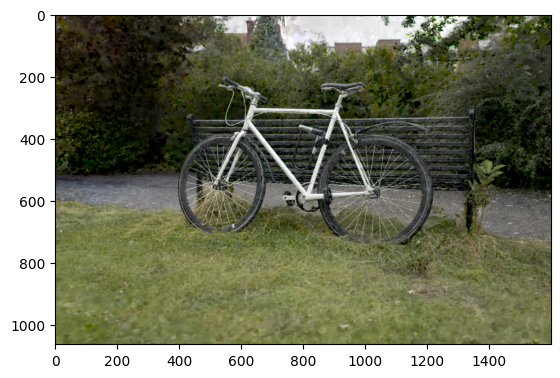

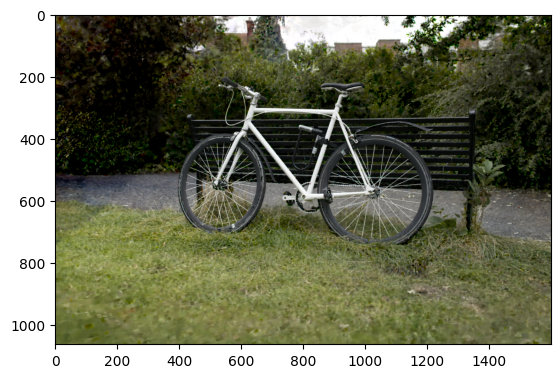

In [244]:
temp_colors = voxel_attribute_field.reshape(-1, 48) @ transformM[:2*3, :48].T
temp_colors = temp_colors.reshape(-1, 2, 3) + 0.5

for i in range(2):
    static_color = torch.from_numpy(temp_colors[:, i, :].astype(np.float32)).cuda()
    tensor_img_target = ref_denfield.apply_phi_with_F(static_color, test_views[0]).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
    plt.imshow(img_target)
    plt.show()



In [245]:
gc.collect()
torch.cuda.empty_cache()

In [246]:
M = transformM[:, :]
MtM = (M.T @ M)
U, S, Vt = np.linalg.svd(MtM)
MtT_sqrt_inv = U @ np.diag(1/np.sqrt(S)) @ Vt

# U =  U[:, np.argsort(S)]
transform = MtM @ MtT_sqrt_inv
inv_transform = MtT_sqrt_inv

X_transformed = (voxel_attribute_field.reshape(-1, 48) @ transform)
variance = np.std(X_transformed, axis=0)
order = np.argsort(-variance)

transform = transform[:, order]
inv_transform = inv_transform[order, :]

X_transformed = (voxel_attribute_field.reshape(-1, 48) @ transform)
np.std(X_transformed, axis=0).reshape((16, 3))


array([[2.986, 2.042, 1.697],
       [1.51 , 1.037, 0.863],
       [0.779, 0.62 , 0.595],
       [0.587, 0.541, 0.456],
       [0.437, 0.417, 0.414],
       [0.406, 0.382, 0.375],
       [0.356, 0.342, 0.311],
       [0.301, 0.297, 0.296],
       [0.29 , 0.26 , 0.258],
       [0.257, 0.251, 0.247],
       [0.244, 0.243, 0.237],
       [0.229, 0.226, 0.223],
       [0.22 , 0.214, 0.211],
       [0.208, 0.207, 0.2  ],
       [0.185, 0.181, 0.175],
       [0.169, 0.168, 0.165]])

In [247]:
XtX = X_transformed.T @ X_transformed
# # C = np.cov(X, rowvar=False)
# # S, U = np.linalg.eig(C)
U, S, V = np.linalg.svd(XtX)
X_transformed_2nd = (X_transformed @ U)



In [248]:

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 16):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs*3] = X_transformed[:, :ncoefs*3]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ inv_transform).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate([test_one_view]):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=16.269675964247593
ncoefs=2, psnr=19.580846945363632
ncoefs=3, psnr=20.94336804340124
ncoefs=4, psnr=22.744055011082235
ncoefs=5, psnr=24.0631351199595
ncoefs=6, psnr=23.95720302091025
ncoefs=7, psnr=24.919471597695292
ncoefs=8, psnr=25.933035567517912
ncoefs=9, psnr=27.5710611145277
ncoefs=10, psnr=27.738011053728417
ncoefs=11, psnr=29.172758468095452
ncoefs=12, psnr=31.650986100995382
ncoefs=13, psnr=33.17693170485395
ncoefs=14, psnr=36.37654802505314
ncoefs=15, psnr=39.264085206709716
psnr=[16.269675964247593, 19.580846945363632, 20.94336804340124, 22.744055011082235, 24.0631351199595, 23.95720302091025, 24.919471597695292, 25.933035567517912, 27.5710611145277, 27.738011053728417, 29.172758468095452, 31.650986100995382, 33.17693170485395, 36.37654802505314, 39.264085206709716]


In [249]:

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 16):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs*3] = X_transformed_2nd[:, :ncoefs*3]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T @ inv_transform).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate([test_one_view]):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=27.681728289159828


ncoefs=2, psnr=30.147357878996527
ncoefs=3, psnr=31.809709027050577
ncoefs=4, psnr=35.984945731659586
ncoefs=5, psnr=39.73271412086823
ncoefs=6, psnr=43.14802449510531
ncoefs=7, psnr=43.990101452580596
ncoefs=8, psnr=45.37098712598187
ncoefs=9, psnr=47.315486324727516
ncoefs=10, psnr=49.80474577242412
ncoefs=11, psnr=50.43885348091614
ncoefs=12, psnr=51.88681504378888
ncoefs=13, psnr=54.70618605947365
ncoefs=14, psnr=58.62108174525887
ncoefs=15, psnr=59.60354031860106
psnr=[27.681728289159828, 30.147357878996527, 31.809709027050577, 35.984945731659586, 39.73271412086823, 43.14802449510531, 43.990101452580596, 45.37098712598187, 47.315486324727516, 49.80474577242412, 50.43885348091614, 51.88681504378888, 54.70618605947365, 58.62108174525887, 59.60354031860106]


# 05 - 2D historgrams of directions -  Lambert Azimuthal Equal‑Area projection

In [206]:
cam_pos = test_views[20].view2world[:3, 3]
all_direction = (voxel_position - cam_pos[np.newaxis, :].numpy())
all_direction = all_direction / (all_direction**2).sum(axis=1, keepdims=True)
all_direction = np.clip(all_direction, a_min=-0.9999, a_max=0.9999)
print(f"all_direction.shape={all_direction.shape}")

projected_direction = all_direction[:, [0, 1]] * (np.sqrt(2 / (1+all_direction[:, [2]])))
upper = np.percentile(projected_direction, 99, axis=0, keepdims=True)
lower = np.percentile(projected_direction, 1, axis=0, keepdims=True)
keep_direction = np.all((projected_direction<=upper) & (projected_direction>=lower), axis=1)
print(f"view_i={view_i} keep_direction.sum()={keep_direction.sum()}")

all_direction.shape=(1936481, 3)
view_i=0 keep_direction.sum()=1864735


In [235]:
all_test_directions = []
for view_i, curr_view in enumerate([test_views[0]]):
    cam_pos = curr_view.view2world[:3, 3]
    all_direction = (voxel_position - cam_pos[np.newaxis, :].numpy())
    all_direction = all_direction / (all_direction**2).sum(axis=1, keepdims=True)
    all_direction = np.clip(all_direction, a_min=-0.9999, a_max=0.9999)    
    projected_direction = all_direction[:, [0, 1]] * (np.sqrt(2 / (1+all_direction[:, [2]])))
    all_test_directions.append(projected_direction)

all_test_directions = np.concatenate(all_test_directions)
upper = np.percentile(all_test_directions, 90, axis=0, keepdims=True)
lower = np.percentile(all_test_directions, 10, axis=0, keepdims=True)
keep_direction = np.all((all_test_directions<=upper) & (all_test_directions>=lower), axis=1)
all_test_directions = all_test_directions[keep_direction, :]
keep_direction.sum()

1370777

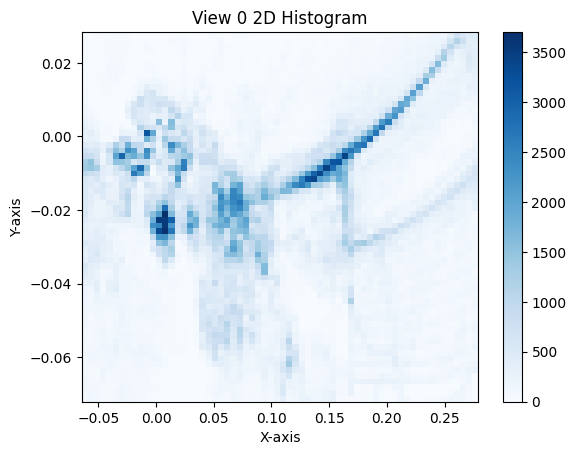

In [252]:

count, bin_x, bin_y, _ = plt.hist2d(all_test_directions[:, 0], all_test_directions[:, 1], bins=64, cmap='Blues')
plt.colorbar()
plt.title('View 0 2D Histogram')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [253]:
i, j = np.where(count>200)
x, y = bin_x[i], bin_y[j]

direction_2D = np.stack([x, y], axis=1)
p = np.sqrt(direction_2D[:, 0]**2 + direction_2D[:, 1]**2)

dir_x = direction_2D[:, 0] * np.sqrt((1 - p**2/4.0) / (p**2))
dir_y = direction_2D[:, 1] * np.sqrt((1 - p**2/4.0) / (p**2))
dir_z = 1 - p**2/2.0

direction_3D = np.stack([dir_x, dir_y, dir_z], axis=1)
direction_3D = direction_3D / np.sqrt((direction_3D**2).sum(axis=1, keepdims=True))

In [254]:
direction_3D

array([[-0.599, -0.378,  0.706],
       [-0.605, -0.367,  0.706],
       [-0.612, -0.356,  0.706],
       ...,
       [ 0.715,  0.062,  0.697],
       [ 0.714,  0.066,  0.697],
       [ 0.714,  0.07 ,  0.697]])

In [255]:
transformM = []
i=0
for dir in direction_3D:
    if i%1000==0:
        print(f"transformM={len(transformM)}")
    out_dir = []
    for c_i in range(16):
        out_c_i = []
        for k in range(3):
            coefs = np.zeros((16, 3))
            coefs[c_i, k] = 1.0
            out_c_i.append(computeColorFromSH(np.array(dir), coefs))
        out_dir.append(out_c_i)
    transformM.append(out_dir)
    i+=1
    
transformM = np.array(transformM)
print(f"transformM.shape={transformM.shape}")
transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(len(direction_3D)*3, 16*3)
print(f"transformM.shape={transformM.shape}")

transformM=0
transformM=1000
transformM.shape=(1708, 16, 3, 3)
transformM.shape=(5124, 48)


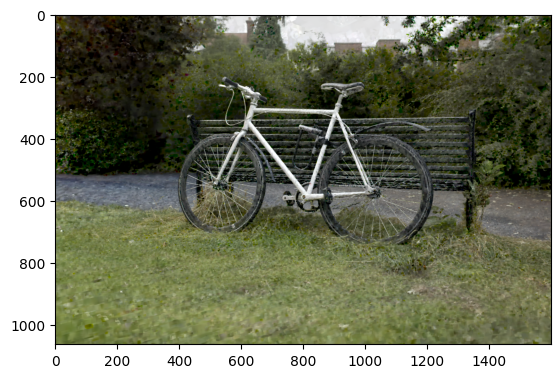

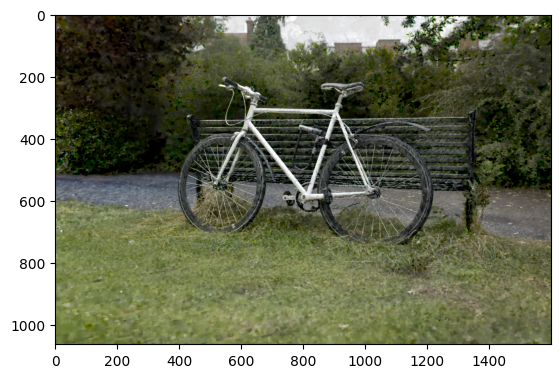

In [256]:
temp_colors = voxel_attribute_field.reshape(-1, 48) @ transformM[:2*3, :48].T
temp_colors = temp_colors.reshape(-1, 2, 3) + 0.5

for i in range(2):
    static_color = torch.from_numpy(temp_colors[:, i, :].astype(np.float32)).cuda()
    tensor_img_target = ref_denfield.apply_phi_with_F(static_color, test_views[0]).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
    plt.imshow(img_target)
    plt.show()



In [257]:
gc.collect()
torch.cuda.empty_cache()

In [259]:
M = transformM[:, :]
MtM = (M.T @ M)
U, S, Vt = np.linalg.svd(MtM)
MtT_sqrt_inv = U @ np.diag(1/np.sqrt(S)) @ Vt

# U =  U[:, np.argsort(S)]
transform = MtM @ MtT_sqrt_inv
inv_transform = MtT_sqrt_inv

X_transformed = (voxel_attribute_field.reshape(-1, 48) @ transform)
variance = np.std(X_transformed, axis=0)
order = np.argsort(-variance)

transform = transform[:, order]
inv_transform = inv_transform[order, :]

X_transformed = (voxel_attribute_field.reshape(-1, 48) @ transform)
np.std(X_transformed, axis=0).reshape((16, 3))


array([[14.489, 11.868,  9.904],
       [ 9.675,  8.266,  8.112],
       [ 7.173,  6.771,  6.664],
       [ 6.508,  6.231,  5.707],
       [ 5.616,  5.236,  5.206],
       [ 5.063,  4.633,  4.578],
       [ 4.449,  4.402,  4.362],
       [ 3.901,  3.796,  3.713],
       [ 3.629,  3.585,  3.316],
       [ 3.256,  3.23 ,  3.211],
       [ 3.066,  3.022,  2.782],
       [ 2.752,  2.713,  2.58 ],
       [ 2.298,  2.165,  2.074],
       [ 1.942,  1.87 ,  1.798],
       [ 1.533,  1.528,  1.475],
       [ 1.329,  1.111,  1.002]])

In [265]:
transform@inv_transform

array([[ 0.969,  0.503,  0.337, ...,  0.   ,  0.   ,  0.   ],
       [-0.243,  1.516,  0.049, ...,  0.   ,  0.   , -0.   ],
       [-0.016,  0.205,  0.4  , ..., -0.   ,  0.   , -0.   ],
       ...,
       [ 0.043, -0.369,  0.121, ...,  1.   , -0.   ,  0.   ],
       [ 0.076, -0.29 ,  0.01 , ..., -0.   ,  1.   ,  0.   ],
       [ 0.009, -0.055, -0.041, ..., -0.   , -0.   ,  1.   ]])

In [260]:
XtX = X_transformed.T @ X_transformed
# # C = np.cov(X, rowvar=False)
# # S, U = np.linalg.eig(C)
U, S, V = np.linalg.svd(XtX)
X_transformed_2nd = (X_transformed @ U)



In [219]:

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 16):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs*3] = X_transformed[:, :ncoefs*3]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ inv_transform).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate([test_one_view]):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=3.9182952394530446
ncoefs=2, psnr=4.3711754412932216
ncoefs=3, psnr=3.50914353692712
ncoefs=4, psnr=3.522689390161338
ncoefs=5, psnr=3.338546140701886
ncoefs=6, psnr=3.540683927282772
ncoefs=7, psnr=3.5498006043480697
ncoefs=8, psnr=3.5159551437693892
ncoefs=9, psnr=3.614079237929208
ncoefs=10, psnr=3.7456946323031035
ncoefs=11, psnr=3.240111927785307
ncoefs=12, psnr=3.857339630422671
ncoefs=13, psnr=4.615149164875461
ncoefs=14, psnr=7.068686897320642
ncoefs=15, psnr=10.178357287283932
psnr=[3.9182952394530446, 4.3711754412932216, 3.50914353692712, 3.522689390161338, 3.338546140701886, 3.540683927282772, 3.5498006043480697, 3.5159551437693892, 3.614079237929208, 3.7456946323031035, 3.240111927785307, 3.857339630422671, 4.615149164875461, 7.068686897320642, 10.178357287283932]


In [220]:

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 16):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs*3] = X_transformed_2nd[:, :ncoefs*3]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T @ inv_transform).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate([test_one_view]):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(-10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=27.186783978562392
ncoefs=2, psnr=29.47804958904609
ncoefs=3, psnr=30.589668207050696
ncoefs=4, psnr=31.272221504325557
ncoefs=5, psnr=31.57683550533203
ncoefs=6, psnr=31.624296009532138
ncoefs=7, psnr=31.68982537805874
ncoefs=8, psnr=37.94270741896942
ncoefs=9, psnr=38.837244654191935
ncoefs=10, psnr=39.344141178303495
ncoefs=11, psnr=40.80456345244137
ncoefs=12, psnr=40.72122733244847
ncoefs=13, psnr=40.86507505417575
ncoefs=14, psnr=40.69261216977551
ncoefs=15, psnr=40.439426118822475
psnr=[27.186783978562392, 29.47804958904609, 30.589668207050696, 31.272221504325557, 31.57683550533203, 31.624296009532138, 31.68982537805874, 37.94270741896942, 38.837244654191935, 39.344141178303495, 40.80456345244137, 40.72122733244847, 40.86507505417575, 40.69261216977551, 40.439426118822475]


# Results Plots

Text(0.5, 1.0, 'Bicycle Scene')

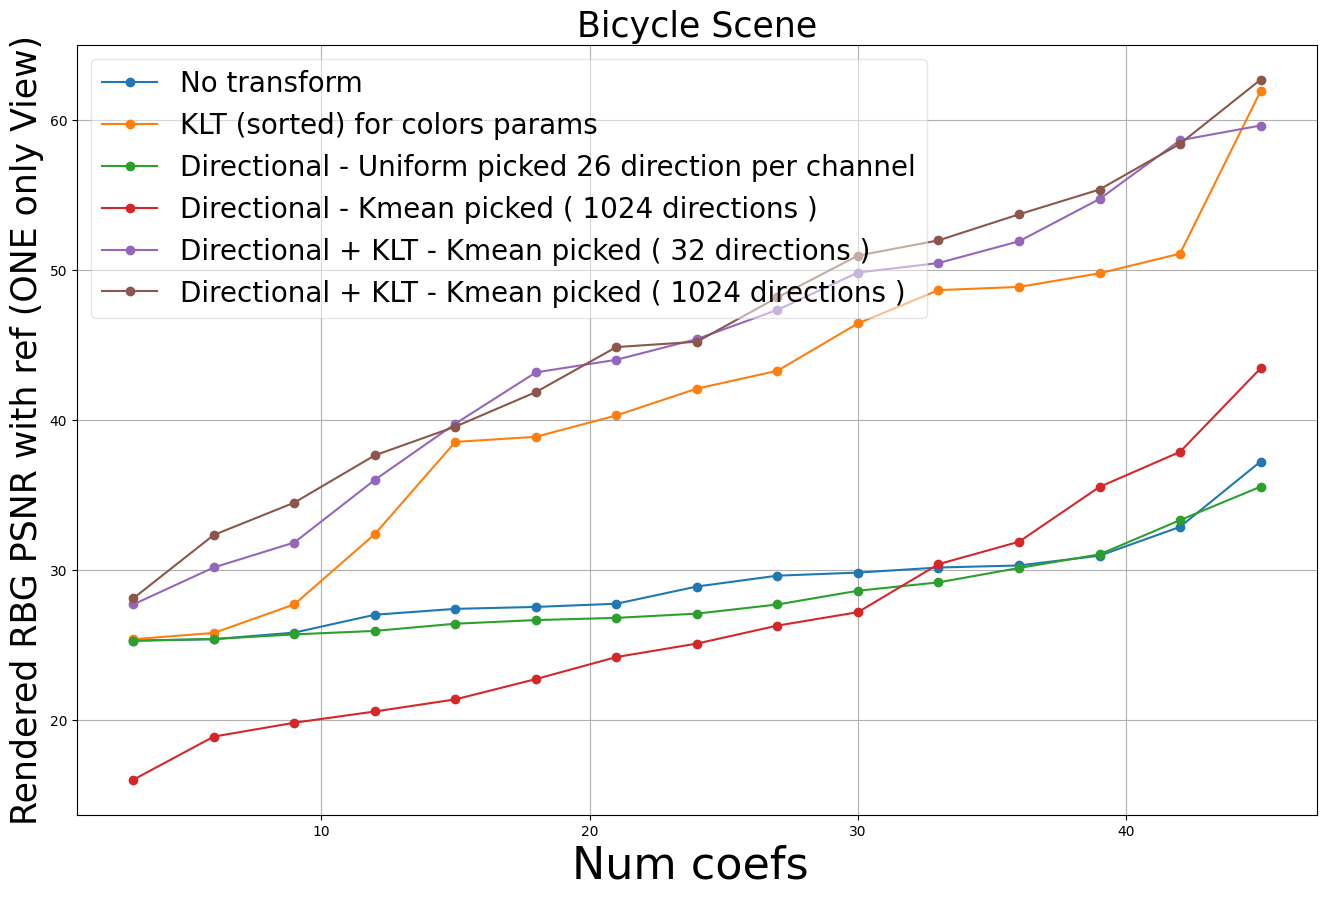

In [251]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 10))


## BASELINE 

psnr=[25.26497661368255, 25.367631757270175, 25.804179162903672, 26.994924532077874, 27.38765063716712, 27.516087865759808, 27.728791933035104, 28.877077292152013, 29.599757026456075, 29.80422063212792, 30.142999624185457, 30.279512053307855, 30.930584154323036, 32.85231262768074, 37.20537381752492]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="No transform")

psnr=[25.362115430345284, 25.783150938596417, 27.683004615419588, 32.36940745656986, 38.516247195627386, 38.857246870797155, 40.28183268807644, 42.067181472179875, 43.25667483836607, 46.413204353839305, 48.63292787592849, 48.845950058006835, 49.75211823882447, 51.0638107361913, 61.888529366262446]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="KLT (sorted) for colors params")

psnr=[25.26497661368255, 25.376685782208682, 25.685495756936774, 25.91752535074872, 26.3979268862148, 26.639972922966066, 26.78533441721889, 27.07044975947297, 27.677933353786784, 28.595840282907417, 29.1523297269612, 30.111677298649816, 31.019269406314205, 33.29977187886776, 35.52964565321595]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="Directional - Uniform picked 26 direction per channel")

# psnr=[15.876045484641516, 18.980390117086746, 19.936023344021837, 21.24838698025313, 21.79600187386218, 23.15645205819216, 23.780233597121395, 26.082728477136953, 27.309885880157925, 29.287117139555644, 30.617014339490872, 32.55641278105253, 35.432733910312805, 37.782866084252106, 42.8167184524403]
# ax.plot(np.arange(1, 16)*3, psnr, '-o', label="Directional - Kmean picked ( 128 directions )")
psnr=[15.997893884628331, 18.87277472221828, 19.79603621257673, 20.545439457137586, 21.353264118821706, 22.70611196144705, 24.17530562407293, 25.071906682136547, 26.27107206356782, 27.167129937530703, 30.365249897912854, 31.860483584789808, 35.51570698620948, 37.85197624632771, 43.418711278778105]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="Directional - Kmean picked ( 1024 directions )")


psnr=[27.681728289159828, 30.147357878996527, 31.809709027050577, 35.984945731659586, 39.73271412086823, 43.14802449510531, 43.990101452580596, 45.37098712598187, 47.315486324727516, 49.80474577242412, 50.43885348091614, 51.88681504378888, 54.70618605947365, 58.62108174525887, 59.60354031860106]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="Directional + KLT - Kmean picked ( 32 directions )")

psnr=[28.08593044811426, 32.312889810592495, 34.46813213502237, 37.621216201714645, 39.53426777635493, 41.835674163974446, 44.83811031256893, 45.19196336127934, 48.148976333546926, 50.93291184827979, 51.94861656022151, 53.684448106477596, 55.338718531000275, 58.387657697472235, 62.65765765166823]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="Directional + KLT - Kmean picked ( 1024 directions )")

############ 
# plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Num coefs ', fontsize=32)
plt.ylabel('Rendered RBG PSNR with ref (ONE only View)', fontsize=25)
plt.title('Bicycle Scene', fontsize=25)

In [37]:
# fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


# ## BASELINE 
# psnr=[23.9083, 24.5693, 25.1598, 25.8635, 26.1601, 26.4003, 26.9967, 27.8473, 28.5388, 29.3123, 29.8021, 30.3615, 31.7934, 34.3099, 38.0124]
# ax.plot(np.arange(1, 16), psnr, '-o', label="No transform")

# psnr=[24.0873, 25.4551, 27.1102, 29.721, 36.0953, 37.4836, 38.7328, 40.5503, 41.9651, 46.0744, 46.8254, 47.2967, 48.6818, 50.8124, 58.0856]
# ax.plot(np.arange(1, 16), psnr, '-o', label="KLT (sorted) for colors params")

# # psnr=[23.8876, 25.2914, 26.8098, 29.1258, 36.0901, 37.4846, 38.7185, 40.4601, 41.7265, 45.8464, 46.4718, 46.8156, 47.2296, 49.0935, 50.9584]
# # ax.plot(np.arange(1, 16), psnr, '-o', label="KLT (old-unsorted) for colors params")


# psnr=[23.9083, 24.6333, 25.2209, 25.9682, 26.2385, 26.4643, 27.02, 27.9293, 28.6322, 29.1693, 29.5388, 30.0412, 31.3221, 33.295, 35.4872]
# ax.plot(np.arange(1, 16), psnr, '-o', label="Colors Transform 26 direction for each channel R,G,B")


# # psnr=[23.9083, 24.6333, 25.2209, 25.9682, 26.2385, 26.4643, 27.02, 27.9293, 28.6322, 29.1693, 29.5388, 30.0412, 31.3221, 33.295, 35.4872]
# # ax.plot(np.arange(1, 16), psnr, '-o', label="Colors Transform - KLT of 26 direction ")


# ############ 
# # plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# # plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
# plt.grid()
# plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
# plt.xlabel('Num triplets coefs ', fontsize=32)
# # plt.xlim((0.3, 2.8))
# # plt.ylim((36, 46.0))
# plt.ylabel('Rendered RBG PSNR (dB) with reference', fontsize=32)
# plt.title('Bicycle Scene', fontsize=32)